# Test 2b - Merge, Aggregate, Visualize

## Introduction

This problem tests your ability to merge, aggregate, and visualize data.
You'll work with realistic business data to answer questions about product profitability.

Before submitting, ensure your notebook:

- Includes your verification info (Banner ID and code) as the first cell
- Runs completely with "Kernel → Restart & Run All"
- Shows your work (don't just print final answers)
- Includes your interpretation responses at the end

## Dataset: Bean & Brew Coffee Shop

You've been hired to analyze sales data for Bean & Brew, a local coffee shop chain with three locations. The owner wants to understand which products are most profitable and how profitability varies across locations.

There are two data files:

- `sales.csv` - Individual transaction records
  - `transaction_id`: Unique transaction identifier
  - `timestamp`: Date and time of purchase (format: 'YYYY-MM-DD HH:MM:SS')
  - `location`: Store location ('Downtown', 'Campus', 'Suburb')
  - `product_id`: Product identifier (links to products table)
  - `quantity`: Number of units sold
  - `revenue`: Total revenue from transaction
  - `payment_method`: Payment type ('Cash', 'Credit', 'Mobile')
  - `loyalty_member`: Boolean indicating if customer is loyalty program member
- `products.csv` - Product catalog
  - `product_id`: Unique product identifier
  - `name`: Product name
  - `category`: Product category ('Coffee', 'Tea', 'Pastry', 'Sandwich')
  - `cost`: Cost to make/acquire one unit (for profit calculation)

The dataset contains two weeks of sales data (approximately 3,000 transactions) across 18 products. It includes both regular and premium items in each category.

We are interested in learning which product categories generate the most profit, and how does profitability vary across locations? Complete the following tasks to answer those questions and more.

## Scoring

Total: 30 points (+ 5 bonus)

- Tasks 1-6: 18 points
- Interpretation (Questions 1-4): 12 points
- Bonus: 5 points (optional)

## Generate Your Dataset

Before starting the analysis, you need to generate your unique dataset using your Banner ID.

1. Open a terminal in the folder containing `generate_test2b_data.py`
2. Activate your conda virtual environment
3. Run: `python generate_test2b_data.py`
4. Enter your 9-digit Banner ID when prompted (you'll enter it twice to confirm)

The script will create two files in the `data/` folder:

- `data/products.csv` - Product catalog
- `data/sales.csv` - Transaction records

Important: At the end, the script displays a verification block like this:

```
======================================================================
DATA VERIFICATION INFORMATION
======================================================================
banner id:          904123456
verification code:  5e0dXXXXXXXX
======================================================================
```

Copy the banner id and verification code lines and paste them into the cell below. This is required for submission.

```
paste your banner id and verification code here...

Banner ID and Verification code:
banner id:          904420117
verification code:  6ea63f519f8b
```

## Setup: Load the Data

Run the cell below to load the data. The code is provided for you.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (provided)
sales = pd.read_csv('data/sales.csv', parse_dates=['timestamp'])
products = pd.read_csv('data/products.csv')

print(f"Sales: {len(sales)} transactions")
print(f"Products: {len(products)} items in catalog")
print()
print("Sales preview:")
sales.head()

Sales: 2713 transactions
Products: 18 items in catalog

Sales preview:


,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member
0,1001,2025-11-09 06:29:00,Suburb,111,1.0,3.83,Credit,True
1,1000,2025-11-09 06:30:00,Suburb,104,1.0,2.73,Credit,False
2,1006,2025-11-09 07:03:00,Downtown,102,1.0,5.25,Mobile,False
3,1007,2025-11-09 07:06:00,Suburb,104,1.0,2.50,Mobile,True
4,1002,2025-11-09 07:07:00,Suburb,107,1.0,1.84,Credit,True


In [2]:
# Products catalog
products

,product_id,name,category,cost
0,101,Espresso,Coffee,1.2
1,102,Cappuccino,Coffee,1.8
2,103,Latte,Coffee,1.9
3,104,Americano,Coffee,1.0
4,105,Cold Brew,Coffee,1.5
5,106,Nitro Cold Brew,Coffee,2.5
6,107,Green Tea,Tea,0.8
7,108,Chai Latte,Tea,1.2
8,109,Herbal Tea,Tea,0.7
9,110,Premium Matcha,Tea,2.2


## Task 1: Data Quality Check

Investigate the sales data quality and coverage. Your code should answer the following questions:

1. How many missing values are in each column?
2. How many unique product IDs appear in the sales data? Compare this to the catalog size.
3. What is the date range (earliest and latest transaction)?

### Your Code

In [3]:
# Task 1: use isna(), nunique(), min/max on timestamp
# Data Quality Check (task 1) 

# Q1. How many missing values are in each column? 
print("Missing values per column:")
print(sales.isna().sum())   # Find number of null values in each colum

#Q2. How many unique product IDs appear in the sales data? Compare this to the catalog size.
unique_sales_products = sales['product_id'].nunique()  # number of unique products in product_id colum for sales
catalog_products = products['product_id'].nunique()    # number of unique products in product_id colum for products

print(f"\nunique product IDs in sales data: {unique_sales_products}")
print(f"number of products in catalog data: {catalog_products}")

# Q3. What is the date range (earliest and latest transaction)?
earliest = sales['timestamp'].min()   # min values
latest = sales['timestamp'].max()     # max value

print(f"\nearliest transaction date: {earliest}")      # print them with descrption 
print(f"latest transaction date:   {latest}")

Missing values per column:
transaction_id    0
timestamp         0
location          0
product_id        0
quantity          7
revenue           3
payment_method    0
loyalty_member    0
dtype: int64

unique product IDs in sales data: 21
number of products in catalog data: 18

earliest transaction date: 2025-11-09 06:29:00
latest transaction date:   2025-11-22 21:30:00


## Task 2: Merge Sales with Products

Merge the sales and products DataFrames to add product information (name, category, cost) to each transaction.

### Your Code

In [4]:
# Task 2: use pd.merge() with appropriate join type

# Merging data 
merged_data = pd.merge(
    sales,
    products, 
    on = 'product_id',
    how = 'left'  # here, add product info, and keep sales rows ( left merge)
)

merged_data.head() # verify merged_data table


,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member,name,category,cost
0,1001,2025-11-09 06:29:00,Suburb,111,1.0,3.83,Credit,True,Croissant,Pastry,1.0
1,1000,2025-11-09 06:30:00,Suburb,104,1.0,2.73,Credit,False,Americano,Coffee,1.0
2,1006,2025-11-09 07:03:00,Downtown,102,1.0,5.25,Mobile,False,Cappuccino,Coffee,1.8
3,1007,2025-11-09 07:06:00,Suburb,104,1.0,2.50,Mobile,True,Americano,Coffee,1.0
4,1002,2025-11-09 07:07:00,Suburb,107,1.0,1.84,Credit,True,Green Tea,Tea,0.8


## Task 3: Verify the Merge

After merging, verify that the merge worked correctly:

1. Compare the shape of the merged DataFrame to the original sales data
2. Check if any rows have missing values in the product columns (name, category, cost)
3. If there are missing values, identify which product_id(s) are causing the problem

### Your Code

In [5]:
# Task 3: check shape, isna() on product columns, filter to find problem IDs

#Q1. Compare shapes 
print("Sales shape: ", sales.shape)                 # shape before merge
print("Merged shape:", merged_data.shape)           # shape after merge

#Q2. Check if any rows have missing values in the product columns
product_columns = ['name', 'category', 'cost']       # assign columns to product_columns (name,category and cost)

print("\nMissing values in product columns:")
print(merged_data[product_columns].isna().sum())     # find number of Nan after merge for the selected colum

#Q3. If there are missing values, identify which product_id(s) are causing the problem
missing_rows = merged_data[merged_data[product_columns].isna().any(axis=1)]       # filter

print("\nNumber of rows with missing product info:", len(missing_rows))     # number of missing rows
print ('\n')
print("Problem in product_id values:")
print(missing_rows['product_id'].unique())    # which product_ids cause the problem
print('\n')
missing_rows.head()

Sales shape:  (2713, 8)
Merged shape: (2713, 11)

Missing values in product columns:
name        13
category    13
cost        13
dtype: int64

Number of rows with missing product info: 13


Problem in product_id values:
[201 199 200]




,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member,name,category,cost
170,1166,2025-11-10 09:43:00,Downtown,201,1.0,4.66,Credit,False,NaN,NaN,NaN
223,1232,2025-11-10 12:39:00,Campus,199,1.0,2.39,Mobile,False,NaN,NaN,NaN
467,1453,2025-11-11 13:43:00,Campus,199,1.0,1.47,Mobile,True,NaN,NaN,NaN
613,1612,2025-11-12 10:57:00,Downtown,201,1.0,9.15,Mobile,False,NaN,NaN,NaN
837,1839,2025-11-13 11:33:00,Downtown,201,1.0,5.42,Credit,False,NaN,NaN,NaN


## Task 4: Profit by Category

First, calculate profit for each transaction: `profit = revenue - (cost × quantity)`

Then summarize profitability by product category. Your code should return a table that shows both total profit and number of transactions for each category. Sort it by total profit (highest first).

### Your Code

In [9]:
# Task 4: create profit column, then groupby with .agg()

# total profit for each transaction
merged_data["profit"] = merged_data["revenue"] - (merged_data["cost"] * merged_data["quantity"])

# group by category and compute total profit + number of transactions
category_summary = merged_data.groupby("category").agg(            ## groupby to return values based on category index
    total_profit=("profit", "sum"),                                ## Sum profits, assign value to total_profit for each category
   num_of_transactions=("transaction_id", "count")                       ## count transactions 
).sort_values(by="total_profit", ascending=False)                  ## sort them in decending order 

category_summary                                                   ## display value


,total_profit,num_of_transactions
category,,
Sandwich,4271.95,603
Coffee,2380.77,963
Pastry,1530.48,531
Tea,849.27,603


## Task 5: Profit by Category and Location

Analyze how profitability varies by both category and location. Your code should produce a table that shows the following for every combination of category and location:

- Total profit
- Average profit per transaction
- Number of transactions

Display the results as a flat table (i.e., without a nested/hierarchical index).

### Your Code

In [22]:
# Task 5: groupby multiple columns, .agg() with dict, reset_index()

# group by category and location ( using .agg)
cat_loc_summary = (
    merged_data
    .groupby(["category", "location"])                      # .agg with dict
    .agg(                                               
         total_profit=("profit", "sum"),                    # total profit
         avg_profit_per_trans=("profit", "mean"),            # average profit per transaction
         num_of_transactions=("transaction_id", "count")    # number of transactions   
    )
    .reset_index()                            # flat table (remove MultiIndex)
)
                                              
cat_loc_summary                               # display values

,category,location,total_profit,avg_profit_per_trans,num_of_transactions
0,Coffee,Campus,1101.13,2.039130,543
1,Coffee,Downtown,1096.05,3.186192,346
2,Coffee,Suburb,183.59,2.480946,74
3,Pastry,Campus,556.37,2.440219,228
4,Pastry,Downtown,613.91,3.448933,178
5,Pastry,Suburb,360.20,2.904839,125
6,Sandwich,Campus,660.10,5.280800,125
7,Sandwich,Downtown,2783.28,8.044162,348
8,Sandwich,Suburb,828.57,6.373615,130
9,Tea,Campus,209.93,1.128656,187


## Task 6: Visualize Category Profitability

Create a bar chart showing total profit by product category. Use seaborn and ensure that the result:

- Has clearly labeled categories
- Includes a descriptive title
- Makes it clear which category is most/least profitable

### Your Code

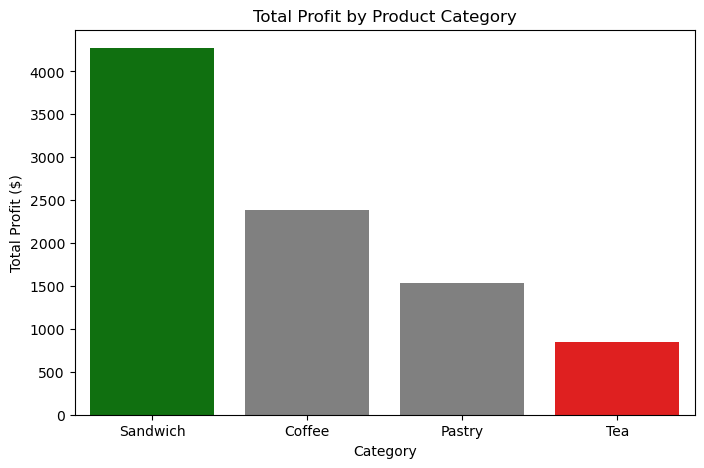

In [30]:
# Task 6: use sns.barplot() with aggregated data

# Assign category summary from task 4 to a new variable and reset category index (make a copy)
plot_data = category_summary.reset_index().copy()

# identify max and min (for colors)
max_pos = plot_data["total_profit"].idxmax()
min_pos = plot_data["total_profit"].idxmin()

# build color list
colors = ["gray"] * len(plot_data)                    # I used this to make categories clear with color
colors[max_pos] = "green"   # highest total profit
colors[min_pos] = "red"     # lowest total profit

# create plot
plt.figure(figsize=(8,5))           # choose appropriate figsize
sns.barplot(                        # seaborn as the question asked
    data=plot_data,
    x="category",
    y="total_profit",
    palette=colors,
    hue="category",                 # I need to use hue to remove warning 
    legend=False                    # the question not asked for legend (legend= false)
)

plt.title("Total Profit by Product Category")      # descrptive title
plt.xlabel("Category")                             # x label (category)
plt.ylabel("Total Profit ($)")                     # y label ( total profit)
plt.show()                                         # display graph

In [33]:
#This task wasn’t required for the exam, but I did it to better support my answer for Interpretation Q3.
location_summary = merged_data.groupby("location").agg(       
    total_profit=("profit", "sum"),
    transactions=("transaction_id", "count")
).sort_values(by="total_profit", ascending=False)

location_summary

,total_profit,transactions
location,,
Downtown,4741.93,1027
Campus,2527.53,1088
Suburb,1763.01,598


## Interpretation

Concisely answer the following questions based on your analysis.


1. What might go wrong if you did not verify the merge in Task 3 before proceeding with the analysis?
2. In Tasks 4 and 5, you aggregated data at different levels of detail (by category, then by category and location). How did this change what you could learn from the data?
3. Reflect on the patterns you discovered in your analysis. What valuable insights did your work generate?
4. The coffee shop owner asks: "Based on your analysis, what's the single most important thing I should do to improve profitability?" Provide a specific, actionable recommendation. Justify your recommendation with evidence from your analysis (include specific numbers from your results). Also, suggest additional analysis that you feel might be worthwhile.

### Your Answers

#### What might go wrong if you did not verify the merge in Task 3 before proceeding with the analysis?
Suppose the Task 3 merge were not validated. In that case, the analysis may yield inaccurate results, as certain information required to calculate profit/aggregates may be missing or distort data, such as product name, product category, or product cost. If we did not align the rows with the matching product IDs, NaN values would propagate in the resultant merged dataframe, with incorrect totals and potentially invalid business decisions. 

#### In Tasks 4 and 5, you aggregated data at different levels of detail (by category, then by category and location). How did this change what you could learn from the data?
Aggregating only by the product category for (Task 4) gave a high-level view of what product category had the highest and lowest profit: Sandwiches were the highest, and Tea the lowest.  
In the next task (Task 5), we aggregate using both categories and location. We can then see how profitable each of the different categories is at the campus, downtown, and suburban level, and also see where specific products sell better or worse than others on a more granular level than category total.

#### Reflect on the patterns you discovered in your analysis. What valuable insights did your work generate?
- ***Groupby (category alone), task 4 analysis:***

**Sandwiches** account for the highest profit category at `$4,271`. **Coffee** is the most frequently sold item at 963 transactions, but it still earns less total profit than Sandwiches despite higher sales volume. **Pastry** generates a moderate profit of `$1,530`, while Tea is the least profitable category at `$849`.

- ***Groupby (location alone):***

Looking at the locations alone, **Downtown** clearly comes out on top, earning a total profit of `$4,741`. The **Campus** location actually sees the most foot traffic with `1,088` transactions, but people there seem to spend less per visit. The **Suburb** location trails behind the others, with only `$1,763` in profit and `598` transactions, revealing that it gets fewer customers and smaller sales overall.

- ***Groupby ( category + location), task 5 analysis:***

Combined category and location data show that **Sandwiches** sold in the **Downtown** location are the strongest segment. **Sandwiches** have the highest total profit of all items for **Downtown** `$2783`. The highest volume of **Coffee** items was sold in **Downtown** `348`; however, they have a lower profit per transaction than **Sandwiches**. **Pastry** has the best profit, with `$614` in the downtown area, due to its market. In the **Suburb**, however, its `360` reflects that it is not widely eaten. **Tea** remains the weakest category across all locations, with consistently low profit totals

#### Recommendation to the coffee shop owner
Increasing sales of Sandwiches in Downtown would result in the highest increase in profit. The Sandwiches have the highest profit margin `($2,783)` and margin overall `($4,272)`. Ultimately, increasing promotion, visibility, combo pricing, or menu offerings of the Sandwiches in the Downtown location would be the best way to improve profits in the short run.

Another improvement concerns Coffee; it has the most transactions `(963)`, but brings in less profit than Sandwiches. I don't know whether it could be due to the price; if we just increase Coffee's price a little, it would improve the profit greatly, yet Coffee is already the most sold item and seems to be a favorite of the customers. (needs price study)

Tea has the lowest total and branch location scores, with totals of `$849` and `$390` in the Suburb location. Because it is so low-scoring, tea is one item which can be replaced in the menu by a better one (not in the Suburb location, since there is still demand for it there). This will allow for less wasted items due to spoilage and more menu space.

The other location, the Suburb, has a total profit of `$1,763`, made from `598` transactions. It sells poorly, and to compete better, the business may advertise more, offer deals and promote to attract more customers.

## Bonus: Time-Based Analysis (Optional)

For extra credit, investigate a time-based question of your choosing. Examples of questions you could explore include:

- Do sales patterns differ between weekdays and weekends?
- Which hours are busiest at each location?
- Is there a day of the week that stands out for profitability?

For full credit you must:

- State your question clearly
- Show your analysis code
- Summarize what you found in 2-3 sentences

In [ ]:
# Bonus: Your time-based analysis here


### Your Findings

*Bonus findings here (state your question and what you discovered)*

## Submission

Ensure your notebook:

- Has the verification block (Banner ID and code) as the first cell
- Runs completely from top to bottom without errors
- Shows all task outputs clearly
- Includes all interpretation responses
- Is saved and committed to your repository

Follow the submission instructions on Canvas to submit your work.